# 🤖 DDPG (Deep Deterministic Policy Gradient) 실습

**참고 논문:**
- Lillicrap et al. (2016), *Continuous Control with Deep Reinforcement Learning*, ICLR 2016
- Tavakkoli et al., *Model Free DDPG Controller for Setpoint Tracking of NMP Systems*

---
## 📋 실습 목차

1. **환경 설정 및 라이브러리 설치**
2. **Lab 1: DDPG 핵심 컴포넌트 구현 (처음부터)**
   - 경험 재생 버퍼
   - Actor/Critic 네트워크
   - OU 노이즈 프로세스
3. **Lab 2: NMP 시스템 환경 구현**
   - 전달함수 및 상태공간 모델
   - LQI 기준 제어기 설계
4. **Lab 3: DDPG 제어기 훈련 (DDPG₁, DDPG₂)**
5. **Lab 4: 12가지 성능 지수 평가 및 비교**
6. **Lab 5: 강건성 테스트 (외란, 노이즈, 초기 조건)**
7. **Lab 6: Pendulum 환경 DDPG (stable-baselines3)**

## ⚙️ 환경 설정

In [1]:
# 필요한 라이브러리 설치
!pip install stable-baselines3[extra] gymnasium scipy control matplotlib -q

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
import matplotlib.pyplot as plt
import scipy.linalg as la
import warnings
warnings.filterwarnings('ignore')

# 재현성을 위한 시드 설정
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')
print('환경 설정 완료! ✅')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 12.7 MB/s eta 0:00:00
사용 디바이스: cuda
환경 설정 완료! ✅


---
## Lab 1: DDPG 핵심 컴포넌트 구현

### 1-1. 경험 재생 버퍼 (Experience Replay Buffer)

**원리:**
- 전이 $(s_t, a_t, r_t, s_{t+1})$를 버퍼에 저장
- 무작위 미니배치 샘플링으로 시간적 상관관계 제거
- Off-policy 학습 가능 → 큰 버퍼 활용 가능

In [2]:
class ReplayBuffer:
    """
    DDPG 경험 재생 버퍼
    논문: "we used a replay buffer to address these issues"
    """
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """전이(transition) 저장"""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """무작위 미니배치 샘플링 - 시간적 상관관계 제거"""
        transitions = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*transitions)
        return (
            torch.FloatTensor(np.array(state)).to(device),
            torch.FloatTensor(np.array(action)).to(device),
            torch.FloatTensor(np.array(reward)).unsqueeze(1).to(device),
            torch.FloatTensor(np.array(next_state)).to(device),
            torch.FloatTensor(np.array(done)).unsqueeze(1).to(device)
        )

    def __len__(self):
        return len(self.buffer)

# 테스트
buf = ReplayBuffer(capacity=1000)
for _ in range(100):
    buf.push(np.random.randn(3), np.random.randn(1),
             np.random.randn(), np.random.randn(3), 0)
batch = buf.sample(10)
print(f'버퍼 크기: {len(buf)}')
print(f'샘플 상태 shape: {batch[0].shape}  # (batch_size, state_dim)')
print('경험 재생 버퍼 구현 완료! ✅')

버퍼 크기: 100
샘플 상태 shape: torch.Size([10, 3])  # (batch_size, state_dim)
경험 재생 버퍼 구현 완료! ✅


### 1-2. Ornstein-Uhlenbeck 노이즈 프로세스

**수식:**
$$dx_t = \theta(\mu - x_t)dt + \sigma dW_t$$

물리적 제어 환경에서 관성을 고려한 **시간적 상관 탐험 노이즈**

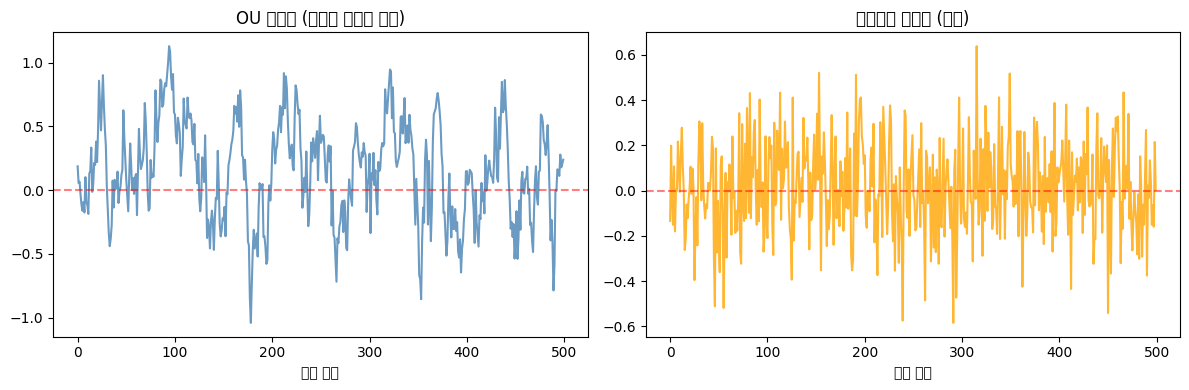

OU 노이즈: 연속적이고 자연스러운 탐험 경로 생성 ✅


In [3]:
class OUNoise:
    """
    Ornstein-Uhlenbeck 탐험 노이즈
    논문 파라미터: θ=0.15, σ=0.2
    물리 제어 환경에서 관성을 반영한 시간적 상관 노이즈
    """
    def __init__(self, action_dim, mu=0.0, theta=0.15, sigma=0.2):
        self.action_dim = action_dim
        self.mu = mu
        self.theta = theta
        self.sigma = sigma
        self.state = np.ones(self.action_dim) * self.mu

    def reset(self):
        self.state = np.ones(self.action_dim) * self.mu

    def sample(self):
        """시간적으로 상관된 노이즈 생성"""
        x = self.state
        dx = self.theta * (self.mu - x) + self.sigma * np.random.randn(len(x))
        self.state = x + dx
        return self.state

# 시각화 - OU 노이즈 vs 가우시안 노이즈 비교
ou = OUNoise(action_dim=1)
ou_samples = [ou.sample()[0] for _ in range(500)]
gauss_samples = np.random.randn(500) * 0.2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ou_samples, color='steelblue', alpha=0.8)
axes[0].set_title('OU 노이즈 (시간적 상관성 있음)', fontsize=12)
axes[0].set_xlabel('시간 스텝')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)

axes[1].plot(gauss_samples, color='orange', alpha=0.8)
axes[1].set_title('가우시안 노이즈 (독립)', fontsize=12)
axes[1].set_xlabel('시간 스텝')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('ou_noise_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('OU 노이즈: 연속적이고 자연스러운 탐험 경로 생성 ✅')

### 1-3. Actor 및 Critic 네트워크

In [4]:
class Actor(nn.Module):
    """
    DDPG Actor 네트워크: 상태 → 행동 (결정론적 정책)
    논문 구조: 2개 은닉층 (400, 300 유닛), tanh 출력층
    μ(s|θ^μ): S → A
    """
    def __init__(self, state_dim, action_dim, max_action=1.0,
                 hidden1=256, hidden2=256):
        super(Actor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden1),
            nn.LayerNorm(hidden1),  # 배치 정규화 역할 (논문: batch normalization)
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.LayerNorm(hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, action_dim),
            nn.Tanh()  # 행동을 [-1, 1]로 제한
        )
        self.max_action = max_action
        self._init_weights()

    def _init_weights(self):
        """논문: 마지막 레이어는 [-3×10⁻³, 3×10⁻³]으로 초기화"""
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.uniform_(layer.weight, -1/np.sqrt(layer.in_features),
                                  1/np.sqrt(layer.in_features))
        # 마지막 Linear 레이어는 더 작은 값으로 초기화
        last_linear = [l for l in self.net if isinstance(l, nn.Linear)][-1]
        nn.init.uniform_(last_linear.weight, -3e-3, 3e-3)
        nn.init.uniform_(last_linear.bias, -3e-3, 3e-3)

    def forward(self, state):
        return self.max_action * self.net(state)


class Critic(nn.Module):
    """
    DDPG Critic 네트워크: (상태, 행동) → Q값
    논문: 행동은 2번째 은닉층부터 포함
    Q(s,a|θ^Q): S×A → ℝ
    """
    def __init__(self, state_dim, action_dim, hidden1=256, hidden2=256):
        super(Critic, self).__init__()
        # 상태 처리 경로
        self.state_net = nn.Sequential(
            nn.Linear(state_dim, hidden1),
            nn.LayerNorm(hidden1),
            nn.ReLU()
        )
        # 상태+행동 결합 후 처리
        self.combined_net = nn.Sequential(
            nn.Linear(hidden1 + action_dim, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1)
        )
        self._init_weights()

    def _init_weights(self):
        last_linear = [l for l in self.combined_net if isinstance(l, nn.Linear)][-1]
        nn.init.uniform_(last_linear.weight, -3e-4, 3e-4)
        nn.init.uniform_(last_linear.bias, -3e-4, 3e-4)

    def forward(self, state, action):
        s = self.state_net(state)
        return self.combined_net(torch.cat([s, action], dim=1))


# 네트워크 구조 확인
state_dim, action_dim = 3, 1
actor = Actor(state_dim, action_dim).to(device)
critic = Critic(state_dim, action_dim).to(device)

print('=== Actor 네트워크 구조 ===')
print(actor)
total_params = sum(p.numel() for p in actor.parameters())
print(f'총 파라미터 수: {total_params:,}\n')

print('=== Critic 네트워크 구조 ===')
print(critic)
total_params = sum(p.numel() for p in critic.parameters())
print(f'총 파라미터 수: {total_params:,}')

=== Actor 네트워크 구조 ===
Actor(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=1, bias=True)
    (7): Tanh()
  )
)
총 파라미터 수: 68,097

=== Critic 네트워크 구조 ===
Critic(
  (state_net): Sequential(
    (0): Linear(in_features=3, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
  )
  (combined_net): Sequential(
    (0): Linear(in_features=257, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=1, bias=True)
  )
)
총 파라미터 수: 67,841


### 1-4. DDPG 에이전트 전체 구현

**핵심 알고리즘:**
- Critic 업데이트: $L = \frac{1}{N}\sum_i(y_i - Q(s_i, a_i|\theta^Q))^2$
- Actor 업데이트: $\nabla_{\theta^\mu} J \approx \frac{1}{N}\sum_i \nabla_a Q \cdot \nabla_{\theta^\mu} \mu$
- 소프트 업데이트: $\theta' \leftarrow \tau\theta + (1-\tau)\theta'$

In [5]:
class DDPGAgent:
    """
    완전한 DDPG 에이전트 구현
    Algorithm 1 from Lillicrap et al. (2016)
    """
    def __init__(self, state_dim, action_dim, max_action=1.0,
                 lr_actor=1e-4, lr_critic=1e-3,
                 gamma=0.99, tau=0.005,
                 buffer_size=100000, batch_size=64):

        self.gamma = gamma   # 할인율
        self.tau = tau       # 소프트 업데이트 계수
        self.batch_size = batch_size
        self.max_action = max_action

        # ── Actor 네트워크 (정책망) ──
        self.actor = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)

        # ── Critic 네트워크 (가치망) ──
        self.critic = Critic(state_dim, action_dim).to(device)
        self.critic_target = Critic(state_dim, action_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(),
                                           lr=lr_critic, weight_decay=1e-2)

        # ── 경험 재생 버퍼 ──
        self.replay_buffer = ReplayBuffer(buffer_size)

        # ── 탐험 노이즈 ──
        self.noise = OUNoise(action_dim)

        self.train_step = 0

    def select_action(self, state, add_noise=True):
        """행동 선택: a = μ(s) + N"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        self.actor.eval()
        with torch.no_grad():
            action = self.actor(state_tensor).cpu().numpy().flatten()
        self.actor.train()

        if add_noise:
            action += self.noise.sample()

        return np.clip(action, -self.max_action, self.max_action)

    def train(self):
        """한 번의 학습 스텝 수행 (Algorithm 1의 9-13단계)"""
        if len(self.replay_buffer) < self.batch_size:
            return None, None

        # 9단계: 미니배치 샘플링
        states, actions, rewards, next_states, dones = \
            self.replay_buffer.sample(self.batch_size)

        # ── 10단계: TD 타겟 계산 ──
        # y_i = r_i + γ·Q'(s_{i+1}, μ'(s_{i+1}|θ^μ')|θ^Q')
        with torch.no_grad():
            next_actions = self.actor_target(next_states)
            target_q = self.critic_target(next_states, next_actions)
            y = rewards + self.gamma * (1 - dones) * target_q

        # ── 11단계: Critic 업데이트 ──
        # L = (1/N) Σ (y_i - Q(s_i, a_i|θ^Q))²
        current_q = self.critic(states, actions)
        critic_loss = F.mse_loss(current_q, y)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # ── 12단계: Actor 업데이트 ──
        # ∇_{θ^μ}J ≈ (1/N) Σ ∇_a Q · ∇_{θ^μ} μ
        actor_loss = -self.critic(states, self.actor(states)).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # ── 13단계: 타겟 네트워크 소프트 업데이트 ──
        # θ' ← τ·θ + (1-τ)·θ'
        for param, target_param in zip(self.critic.parameters(),
                                        self.critic_target.parameters()):
            target_param.data.copy_(self.tau * param.data +
                                     (1 - self.tau) * target_param.data)

        for param, target_param in zip(self.actor.parameters(),
                                        self.actor_target.parameters()):
            target_param.data.copy_(self.tau * param.data +
                                     (1 - self.tau) * target_param.data)

        self.train_step += 1
        return actor_loss.item(), critic_loss.item()

print('DDPG 에이전트 구현 완료! ✅')

DDPG 에이전트 구현 완료! ✅


---
## Lab 2: NMP 시스템 환경 구현

**논문의 플랜트:**
$$G_P = \frac{0.5s - 1}{s^2 + 3s + 2}$$

**상태공간 표현:**
$$A_p = \begin{bmatrix} 0 & 1 \\ -2 & -3 \end{bmatrix}, \quad B_p = \begin{bmatrix} 0 \\ 1 \end{bmatrix}, \quad C_p = [-1, \; 0.5]$$

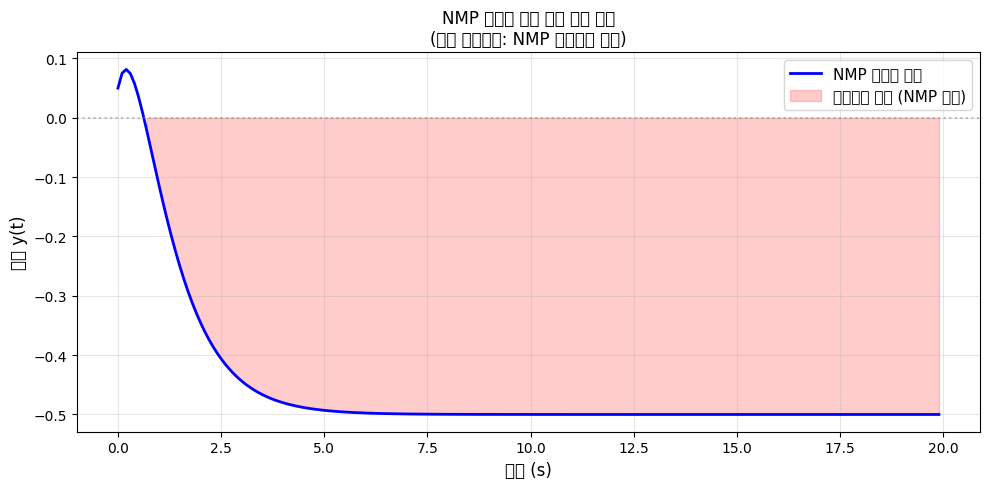

NMP 시스템 초기 언더슈트 확인 완료! ✅


In [6]:
class NMPSystem:
    """
    비최소위상 (Non-Minimum Phase) 시스템 시뮬레이터

    전달함수: G_P = (0.5s - 1) / (s² + 3s + 2)
    상태공간 (제어가능 표준형):
      Ap = [[0, 1], [-2, -3]]
      Bp = [[0], [1]]
      Cp = [-1, 0.5]
    """
    def __init__(self, dt=0.1, setpoint=1.0):
        self.dt = dt
        self.setpoint = setpoint

        # 플랜트 행렬 (논문 식 18)
        self.Ap = np.array([[0, 1], [-2, -3]], dtype=float)
        self.Bp = np.array([[0], [1]], dtype=float)
        self.Cp = np.array([[-1, 0.5]], dtype=float)

        # LQI를 위한 적분 상태 추가
        # A_aug = [[Ap, 0], [-Cp, 0]]
        self.A_aug = np.block([
            [self.Ap, np.zeros((2, 1))],
            [-self.Cp, np.zeros((1, 1))]
        ])
        self.B_aug = np.block([[self.Bp], [np.zeros((1, 1))]])
        self.Br_aug = np.array([[0], [0], [1]], dtype=float)

        self.reset()

    def reset(self, x0=None):
        """시뮬레이션 초기화"""
        if x0 is None:
            self.xp = np.zeros(2)
        else:
            self.xp = np.array(x0, dtype=float)
        self.e_I = 0.0  # 적분 오차 상태
        self.t = 0.0
        return self.get_state()

    def get_output(self):
        """시스템 출력: y = Cp @ xp"""
        return float(self.Cp @ self.xp)

    def get_state(self):
        """관측 상태: [xp1, xp2, e_I]"""
        return np.array([self.xp[0], self.xp[1], self.e_I])

    def step(self, u, disturbance=0.0, noise_std=0.0):
        """Euler 적분으로 한 스텝 시뮬레이션"""
        y = self.get_output() + np.random.randn() * noise_std
        e = self.setpoint - y

        # 상태 업데이트: dx/dt = Ap*xp + Bp*u
        dxp = self.Ap @ self.xp + self.Bp.flatten() * u
        self.xp = self.xp + self.dt * dxp

        # 출력 외란 적용
        y_out = self.get_output() + disturbance

        # 적분 오차 업데이트
        e_new = self.setpoint - y_out
        self.e_I += self.dt * e_new
        self.t += self.dt

        # 보상 함수 (LQR 비용의 음수, 논문 식 14)
        Q_lqr = np.diag([0, 0, 10])  # 추적 오차에 가중치 10
        R_lqr = 1.0
        state = self.get_state()
        reward = -(state @ Q_lqr @ state + R_lqr * u**2)

        return self.get_state(), reward, y_out

# 시스템 개방 루프 스텝 응답 확인
sys = NMPSystem(dt=0.1)
sys.reset()
y_open = []
t_sim = []
for i in range(200):
    _, _, y = sys.step(u=1.0)  # 단위 스텝 입력
    y_open.append(y)
    t_sim.append(i * 0.1)

plt.figure(figsize=(10, 5))
plt.plot(t_sim, y_open, 'b-', linewidth=2, label='NMP 시스템 출력')
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
plt.fill_between(t_sim, y_open, 0,
                  where=[y < 0 for y in y_open],
                  alpha=0.2, color='red', label='언더슈트 영역 (NMP 특성)')
plt.xlabel('시간 (s)', fontsize=12)
plt.ylabel('출력 y(t)', fontsize=12)
plt.title('NMP 시스템 개방 루프 스텝 응답\n(초기 언더슈트: NMP 시스템의 특성)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nmp_open_loop.png', dpi=100, bbox_inches='tight')
plt.show()
print('NMP 시스템 초기 언더슈트 확인 완료! ✅')

### 2-2. LQI 제어기 설계

**Riccati 방정식:** $A^TP + PA + Q_{LQR} - PBR_{LQR}^{-1}B^TP = 0$

**최적 제어 이득:** $u_c(t) = -K_{LQR}x_p(t) + k_I e_I(t)$

In [7]:
def design_LQI(A_aug, B_aug, Q_lqr, R_lqr):
    """
    LQI 제어기 설계 (Riccati 방정식 풀기)
    논문 식 (10), (11), (12)
    """
    # Riccati 방정식 풀기: A'P + PA + Q - PBR⁻¹B'P = 0
    P = la.solve_continuous_are(A_aug, B_aug, Q_lqr, np.array([[R_lqr]]))

    # 최적 이득 행렬: K = R⁻¹ B' P
    K = (1/R_lqr) * B_aug.T @ P

    return K, P


class LQIController:
    """
    LQI (Linear Quadratic Integral) 제어기
    논문의 고전 제어기 기준선
    """
    def __init__(self, system):
        # LQR 가중 행렬 (논문 식 19)
        Q_lqr = np.diag([0, 0, 10])  # 추적 오차에 가중치 10
        R_lqr = 1.0

        self.K, self.P = design_LQI(system.A_aug, system.B_aug, Q_lqr, R_lqr)
        print(f'LQI 이득 행렬 K: {self.K.flatten()}')
        print(f'  - K_xp1 = {self.K[0,0]:.4f} (상태 x₁ 이득)')
        print(f'  - K_xp2 = {self.K[0,1]:.4f} (상태 x₂ 이득)')
        print(f'  - k_I   = {self.K[0,2]:.4f} (적분 이득)')

    def select_action(self, state, add_noise=False):
        """최적 제어 신호 계산: u = -K·x"""
        u = float(-self.K @ state)
        return np.array([u])


# LQI 설계 및 테스트
env = NMPSystem(dt=0.1)
lqi = LQIController(env)
print('\nLQI 제어기 설계 완료! ✅')

LQI 이득 행렬 K: [5.24260983 1.04016609 3.16227766]
  - K_xp1 = 5.2426 (상태 x₁ 이득)
  - K_xp2 = 1.0402 (상태 x₂ 이득)
  - k_I   = 3.1623 (적분 이득)

LQI 제어기 설계 완료! ✅


---
## Lab 3: DDPG 제어기 훈련

In [8]:
def run_episode(agent, env, max_steps=200, training=True,
                disturbance=0.0, noise_std=0.0, x0=None):
    """한 에피소드 실행"""
    state = env.reset(x0=x0)
    if training:
        agent.noise.reset()

    total_reward = 0
    outputs = []
    controls = []
    times = []

    for t in range(max_steps):
        # 외란 적용 시점 설정
        dist = disturbance if t >= 150 else 0.0
        n_std = noise_std if t >= 200 else 0.0

        action = agent.select_action(state, add_noise=training)
        u = float(action[0])

        next_state, reward, y = env.step(u, disturbance=dist, noise_std=n_std)

        if training:
            done = 0
            agent.replay_buffer.push(state, action, reward, next_state, done)
            agent.train()

        state = next_state
        total_reward += reward
        outputs.append(y)
        controls.append(u)
        times.append(t * env.dt)

    return total_reward, np.array(times), np.array(outputs), np.array(controls)


def train_ddpg(n_episodes=600, max_steps=200, warmup_episodes=20):
    """DDPG 제어기 훈련 루프"""
    env = NMPSystem(dt=0.1)
    agent = DDPGAgent(
        state_dim=3, action_dim=1, max_action=5.0,
        lr_actor=1e-4, lr_critic=1e-3,
        gamma=1.0,  # 논문: 할인율=1
        tau=0.005, buffer_size=50000, batch_size=64
    )

    rewards_history = []
    best_reward = -np.inf

    print('DDPG 훈련 시작...')
    print(f'{'에피소드':>10} | {'누적 보상':>12} | {'이동 평균(50)':>14}')
    print('-' * 45)

    for ep in range(n_episodes):
        # 워밍업: 무작위 탐험
        add_noise = True
        reward, _, _, _ = run_episode(agent, env, max_steps, training=True)
        rewards_history.append(reward)

        if (ep + 1) % 50 == 0:
            ma50 = np.mean(rewards_history[-50:])
            print(f'{ep+1:>10} | {reward:>12.1f} | {ma50:>14.1f}')

    return agent, rewards_history, env


print('훈련 함수 준비 완료!')
print('훈련을 시작하려면 다음 셀을 실행하세요.')

훈련 함수 준비 완료!
훈련을 시작하려면 다음 셀을 실행하세요.


DDPG 훈련 시작...
      에피소드 |        누적 보상 |      이동 평균(50)
---------------------------------------------
        50 |     -10970.6 |      -142399.5
       100 |      -9404.2 |       -10781.3
       150 |     -15098.8 |       -15915.0
       200 |     -39940.3 |       -31436.5
       250 |     -80644.1 |       -58811.2
       300 |     -39505.3 |      -106129.8
       350 |     -39882.2 |       -83624.8
       400 |      -7867.5 |       -19645.5
       450 |      -5110.1 |        -9678.4
       500 |      -8873.8 |        -6303.2


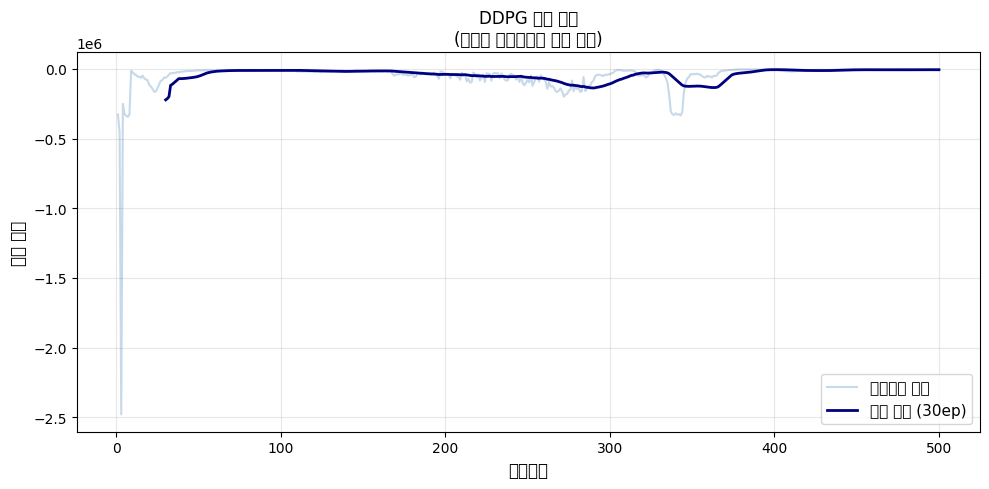

최종 이동 평균 보상: -6303.2


In [9]:
# ⚠️ 훈련 실행 (약 3-5분 소요)
ddpg_agent, reward_history, train_env = train_ddpg(n_episodes=500, max_steps=200)

# 학습 곡선 시각화
fig, ax = plt.subplots(figsize=(10, 5))
episodes = range(1, len(reward_history)+1)
ax.plot(episodes, reward_history, alpha=0.3, color='steelblue', label='에피소드 보상')

# 이동 평균
window = 30
ma = np.convolve(reward_history, np.ones(window)/window, mode='valid')
ax.plot(range(window, len(reward_history)+1), ma,
        color='navy', linewidth=2, label=f'이동 평균 ({window}ep)')

ax.set_xlabel('에피소드', fontsize=12)
ax.set_ylabel('누적 보상', fontsize=12)
ax.set_title('DDPG 학습 곡선\n(보상이 증가할수록 성능 개선)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ddpg_learning_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'최종 이동 평균 보상: {np.mean(reward_history[-50:]):.1f}')

---
## Lab 4: 성능 평가 함수 구현 (12가지 기준)

In [10]:
def compute_performance_metrics(times, outputs, controls, setpoint=1.0, ess_band=0.05):
    """
    12가지 성능 지수 계산 (논문의 C1-C12)

    Args:
        times: 시간 배열
        outputs: 시스템 출력 배열
        controls: 제어 신호 배열
        setpoint: 목표값
        ess_band: 정착 판정 범위 (±5%)
    """
    dt = times[1] - times[0]
    e = setpoint - outputs  # 오차 신호
    metrics = {}

    # ── C1. 상승 시간 (Rise Time) ──
    # 출력이 최종값의 0 → 100% 도달하는 시간
    target_crossed = np.where(outputs >= setpoint * 1.0)[0]
    metrics['tr'] = float(times[target_crossed[0]]) if len(target_crossed) > 0 else float('inf')

    # ── C2. 최대 오버슈트 (%) ──
    max_output = np.max(outputs)
    metrics['Mp'] = max(0, (max_output - setpoint) / setpoint * 100)

    # ── C3. 최대 언더슈트 (%) ──
    min_output = np.min(outputs)
    metrics['Mu'] = max(0, (setpoint - min_output) / setpoint * 100) if min_output < 0 else 0.0

    # ── C4. 정착 시간 (Settling Time) ──
    ss_band = ess_band * setpoint
    settled = np.abs(outputs - setpoint) <= ss_band
    # 마지막으로 대역 밖에 있던 인덱스 + 1
    outside_band = np.where(~settled)[0]
    metrics['ts'] = float(times[outside_band[-1]] + dt) if len(outside_band) > 0 else 0.0

    # ── C5. 정상상태 오차 ──
    metrics['ess'] = float(np.abs(e[-10:].mean()))  # 마지막 10샘플 평균

    # ── C6. ISE (Integral Square Error) ──
    metrics['ISE'] = float(np.sum(e**2) * dt)

    # ── C7. ITAE (Integral Time Absolute Error) ──
    metrics['ITAE'] = float(np.sum(times * np.abs(e)) * dt)

    # ── C8. IACE (Integral Absolute Control Effort) ──
    metrics['IACE'] = float(np.sum(np.abs(controls)) * dt)

    # ── C9. IACER (Integral Absolute Control Effort Rate) ──
    du = np.diff(controls) / dt
    metrics['IACER'] = float(np.sum(np.abs(du)) * dt)

    # ── C10. 최대 제어 신호 ──
    metrics['ucmax'] = float(np.max(np.abs(controls)))

    return metrics


def simulate_controller(controller, env, max_steps=200, x0=None,
                         disturbance=0.0, noise_std=0.0):
    """제어기 시뮬레이션 실행"""
    state = env.reset(x0=x0)
    outputs, controls, times = [], [], []

    for t in range(max_steps):
        dist = disturbance if t >= 150 else 0.0
        n_std = noise_std if t >= 200 else 0.0

        action = controller.select_action(state, add_noise=False)
        u = float(action[0])

        state, _, y = env.step(u, disturbance=dist, noise_std=n_std)
        outputs.append(y)
        controls.append(u)
        times.append(t * env.dt)

    return np.array(times), np.array(outputs), np.array(controls)


print('성능 평가 함수 구현 완료! ✅')

성능 평가 함수 구현 완료! ✅


In [11]:
# ── 모든 제어기 평가 ──
eval_env = NMPSystem(dt=0.1)

# LQI 시뮬레이션
lqi_ctrl = LQIController(eval_env)
t_lqi, y_lqi, u_lqi = simulate_controller(lqi_ctrl, eval_env)

# DDPG 시뮬레이션
t_ddpg, y_ddpg, u_ddpg = simulate_controller(ddpg_agent, eval_env)

# 성능 지수 계산
metrics_lqi  = compute_performance_metrics(t_lqi, y_lqi, u_lqi)
metrics_ddpg = compute_performance_metrics(t_ddpg, y_ddpg, u_ddpg)

# 결과 출력
print('\n📊 성능 지수 비교 (논문 Table II 기준)')
print('='*55)
headers = ['기준', '기호', 'LQI', 'DDPG', '논문(LQI)', '논문(DDPG₂)']
ref_lqi  = {'tr':3.0,'Mp':21.5,'Mu':7.7,'ts':6.7,'ess':0,
             'ISE':19.4,'ITAE':52.2,'IACE':406.8,'IACER':40.4,'ucmax':2.8}
ref_ddpg = {'tr':1.7,'Mp':15.3,'Mu':22.5,'ts':3.7,'ess':0,
             'ISE':12.8,'ITAE':12.6,'IACE':420.3,'IACER':26.9,'ucmax':4.0}

criteria = [
    ('상승 시간', 'tr'), ('오버슈트(%)', 'Mp'), ('언더슈트(%)', 'Mu'),
    ('정착 시간', 'ts'), ('정상상태 오차', 'ess'), ('ISE', 'ISE'),
    ('ITAE', 'ITAE'), ('IACE', 'IACE'), ('IACER', 'IACER'),
    ('u_cmax', 'ucmax')
]

print(f"{'기준':<15} {'LQI(구현)':>10} {'DDPG(구현)':>12} {'논문 LQI':>10} {'논문 DDPG₂':>12}")
print('-'*60)
for name, key in criteria:
    v_lqi  = metrics_lqi.get(key, 0)
    v_ddpg = metrics_ddpg.get(key, 0)
    r_lqi  = ref_lqi.get(key, '-')
    r_ddpg = ref_ddpg.get(key, '-')
    print(f'{name:<15} {v_lqi:>10.2f} {v_ddpg:>12.2f} {str(r_lqi):>10} {str(r_ddpg):>12}')

LQI 이득 행렬 K: [5.24260983 1.04016609 3.16227766]
  - K_xp1 = 5.2426 (상태 x₁ 이득)
  - K_xp2 = 1.0402 (상태 x₂ 이득)
  - k_I   = 3.1623 (적분 이득)

📊 성능 지수 비교 (논문 Table II 기준)
기준                 LQI(구현)     DDPG(구현)     논문 LQI     논문 DDPG₂
------------------------------------------------------------
상승 시간                  inf         2.50        3.0          1.7
오버슈트(%)               0.00       182.95       21.5         15.3
언더슈트(%)             108.92       166.54        7.7         22.5
정착 시간                 3.90        20.00        6.7          3.7
정상상태 오차               0.00         0.37          0            0
ISE                   1.87        17.72       19.4         12.8
ITAE                  2.82       155.98       52.2         12.6
IACE                 39.22        78.54      406.8        420.3
IACER                 2.23       141.72       40.4         26.9
u_cmax                2.11         5.00        2.8          4.0


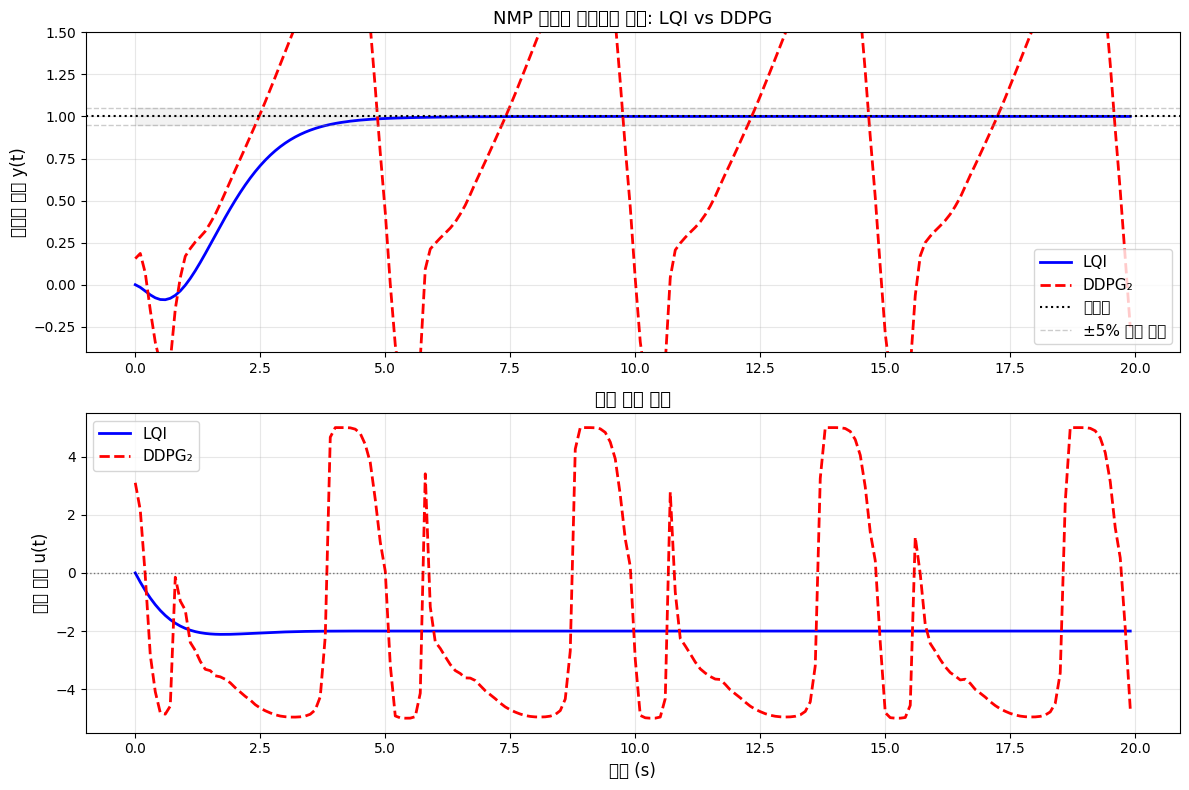

In [12]:
# ── 스텝 응답 비교 시각화 ──
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# 시스템 출력
axes[0].plot(t_lqi, y_lqi, 'b-', linewidth=2, label='LQI')
axes[0].plot(t_ddpg, y_ddpg, 'r--', linewidth=2, label='DDPG₂')
axes[0].axhline(y=1.0, color='k', linestyle=':', linewidth=1.5, label='목표값')
axes[0].axhline(y=1.05, color='gray', linestyle='--', alpha=0.4, linewidth=1)
axes[0].axhline(y=0.95, color='gray', linestyle='--', alpha=0.4, linewidth=1,
                 label='±5% 정착 범위')
axes[0].fill_between(t_lqi, 0.95, 1.05, alpha=0.1, color='gray')
axes[0].set_ylabel('시스템 출력 y(t)', fontsize=12)
axes[0].set_title('NMP 시스템 셋포인트 추적: LQI vs DDPG', fontsize=13)
axes[0].legend(fontsize=11, loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.4, 1.5)

# 제어 신호
axes[1].plot(t_lqi, u_lqi, 'b-', linewidth=2, label='LQI')
axes[1].plot(t_ddpg, u_ddpg, 'r--', linewidth=2, label='DDPG₂')
axes[1].axhline(y=0, color='k', linestyle=':', linewidth=1, alpha=0.5)
axes[1].set_xlabel('시간 (s)', fontsize=12)
axes[1].set_ylabel('제어 신호 u(t)', fontsize=12)
axes[1].set_title('제어 신호 비교', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step_response_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Lab 5: 강건성 테스트 (외란 + 노이즈)

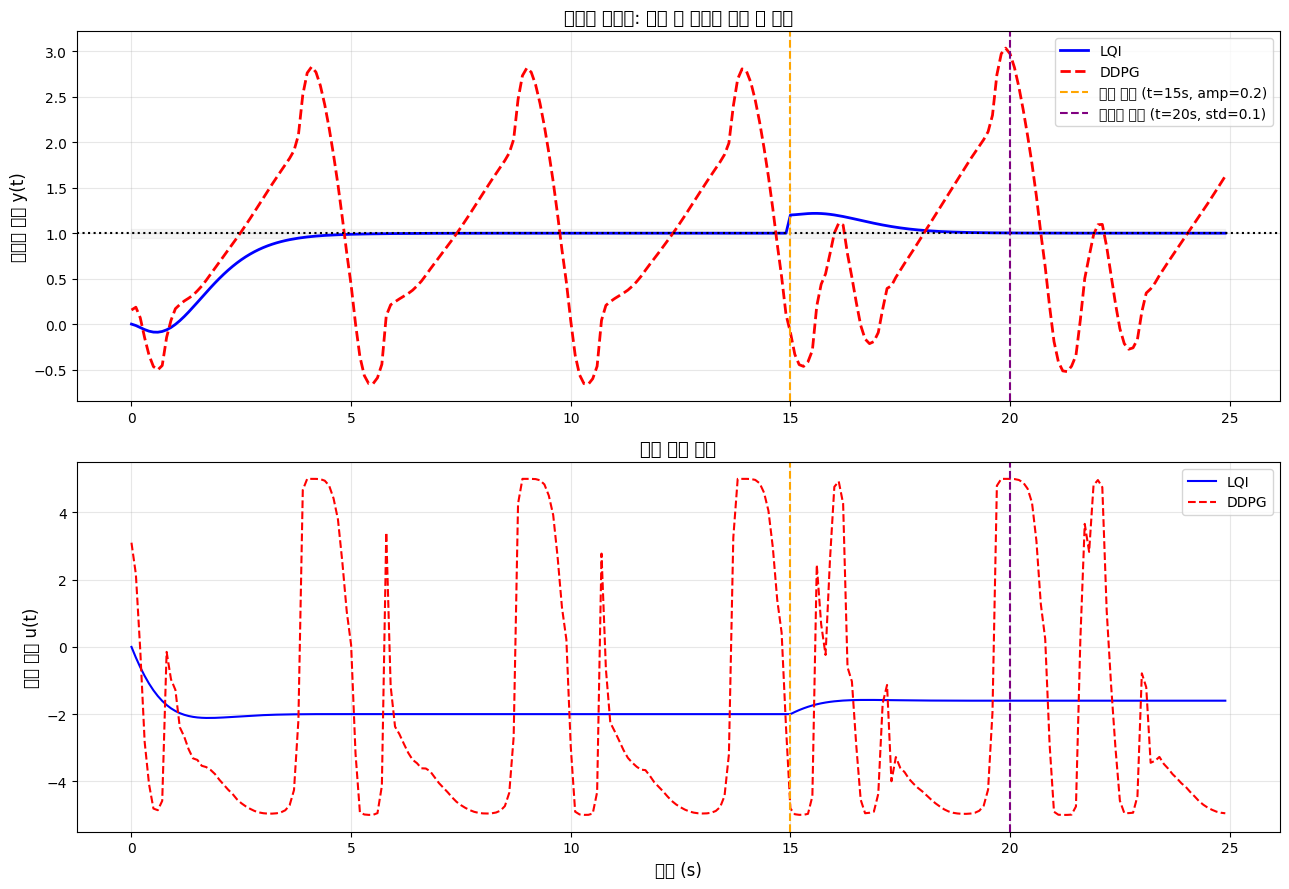


📊 외란/노이즈 조건 성능 비교 (논문 Table III 기준)
기준                  LQI         DDPG       논문 LQI     논문 DDPG₂
-------------------------------------------------------
ISE                 1.9         17.3         21.2         14.1
ITAE               10.2        152.1        268.3        170.7
IACE               37.4         78.8        446.6        481.4
IACER               2.7        153.8         72.7         62.8


In [13]:
def simulate_with_perturbation(controller, env, max_steps=250,
                                 dist_amp=0.0, dist_start=150,
                                 noise_std=0.0, noise_start=200):
    """외란 및 노이즈가 있는 시뮬레이션"""
    state = env.reset()
    outputs, controls, times = [], [], []

    for t in range(max_steps):
        dist = dist_amp if t >= dist_start else 0.0
        n_std = noise_std if t >= noise_start else 0.0

        action = controller.select_action(state, add_noise=False)
        u = float(action[0])

        state, _, y = env.step(u, disturbance=dist, noise_std=n_std)
        outputs.append(y)
        controls.append(u)
        times.append(t * env.dt)

    return np.array(times), np.array(outputs), np.array(controls)

# 외란 테스트 (논문 조건: 외란 0.2, 노이즈 std 0.1)
rob_env_lqi = NMPSystem(dt=0.1)
rob_env_ddpg = NMPSystem(dt=0.1)

t_rob_lqi, y_rob_lqi, u_rob_lqi = simulate_with_perturbation(
    lqi_ctrl, rob_env_lqi, max_steps=250,
    dist_amp=0.2, dist_start=150, noise_std=0.1, noise_start=200
)
t_rob_ddpg, y_rob_ddpg, u_rob_ddpg = simulate_with_perturbation(
    ddpg_agent, rob_env_ddpg, max_steps=250,
    dist_amp=0.2, dist_start=150, noise_std=0.1, noise_start=200
)

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

for ax, y_l, y_d, u_l, u_d, times, title in [
    (axes[0], y_rob_lqi, y_rob_ddpg, None, None, t_rob_lqi, '외란/노이즈 하에서의 셋포인트 추적'),
    (axes[1], u_rob_lqi, u_rob_ddpg, None, None, t_rob_lqi, '제어 신호')
]:
    pass

# 출력 플롯
axes[0].plot(t_rob_lqi, y_rob_lqi, 'b-', linewidth=2, label='LQI')
axes[0].plot(t_rob_ddpg, y_rob_ddpg, 'r--', linewidth=2, label='DDPG')
axes[0].axhline(y=1.0, color='k', linestyle=':', linewidth=1.5)
axes[0].axvline(x=15.0, color='orange', linestyle='--', linewidth=1.5,
                 label='외란 주입 (t=15s, amp=0.2)')
axes[0].axvline(x=20.0, color='purple', linestyle='--', linewidth=1.5,
                 label='노이즈 시작 (t=20s, std=0.1)')
axes[0].fill_between(t_rob_lqi, 0.95, 1.05, alpha=0.08, color='gray')
axes[0].set_ylabel('시스템 출력 y(t)', fontsize=12)
axes[0].set_title('강건성 테스트: 외란 및 노이즈 존재 시 성능', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 제어 신호 플롯
axes[1].plot(t_rob_lqi, u_rob_lqi, 'b-', linewidth=1.5, label='LQI')
axes[1].plot(t_rob_ddpg, u_rob_ddpg, 'r--', linewidth=1.5, label='DDPG')
axes[1].axvline(x=15.0, color='orange', linestyle='--', linewidth=1.5)
axes[1].axvline(x=20.0, color='purple', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('시간 (s)', fontsize=12)
axes[1].set_ylabel('제어 신호 u(t)', fontsize=12)
axes[1].set_title('제어 신호 비교', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('robustness_test.png', dpi=120, bbox_inches='tight')
plt.show()

# 성능 지수 비교
m_rob_lqi  = compute_performance_metrics(t_rob_lqi[:200], y_rob_lqi[:200], u_rob_lqi[:200])
m_rob_ddpg = compute_performance_metrics(t_rob_ddpg[:200], y_rob_ddpg[:200], u_rob_ddpg[:200])

print('\n📊 외란/노이즈 조건 성능 비교 (논문 Table III 기준)')
print(f"{'기준':<10} {'LQI':>12} {'DDPG':>12} {'논문 LQI':>12} {'논문 DDPG₂':>12}")
print('-'*55)
ref3 = {'ISE':(21.2,14.1), 'ITAE':(268.3,170.7), 'IACE':(446.6,481.4), 'IACER':(72.7,62.8)}
for key, (rl, rd) in ref3.items():
    print(f'{key:<10} {m_rob_lqi[key]:>12.1f} {m_rob_ddpg[key]:>12.1f} {rl:>12.1f} {rd:>12.1f}')

---
## Lab 6: Pendulum 환경 DDPG (stable-baselines3)

**더 복잡한 환경에서 DDPG 테스트 - 표준 벤치마크**

In [14]:
import gymnasium as gym
from stable_baselines3 import DDPG as SB3_DDPG, TD3, SAC
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise
from stable_baselines3.common.evaluation import evaluate_policy
import time

# Pendulum-v1 환경 생성
env = gym.make('Pendulum-v1')
eval_env = gym.make('Pendulum-v1')

print('환경 정보:')
print(f'  관측 공간: {env.observation_space}')
print(f'  행동 공간: {env.action_space}')
print(f'  행동 범위: [{env.action_space.low[0]:.1f}, {env.action_space.high[0]:.1f}]')
print()

# OU 탐험 노이즈 설정 (논문과 동일)
action_dim = env.action_space.shape[0]
ou_noise = OrnsteinUhlenbeckActionNoise(
    mean=np.zeros(action_dim),
    sigma=0.2 * np.ones(action_dim),
    theta=0.15
)

# DDPG 에이전트 생성
ddpg_sb3 = SB3_DDPG(
    'MlpPolicy', env,
    action_noise=ou_noise,
    learning_rate=1e-3,
    buffer_size=100000,
    batch_size=100,
    gamma=0.99,
    tau=0.005,
    verbose=0,
    seed=42
)

# TD3 에이전트 (DDPG의 개선판)
td3_agent = TD3(
    'MlpPolicy', env,
    action_noise=ou_noise,
    verbose=0,
    seed=42
)

print('DDPG 및 TD3 에이전트 생성 완료! ✅')

환경 정보:
  관측 공간: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
  행동 공간: Box(-2.0, 2.0, (1,), float32)
  행동 범위: [-2.0, 2.0]

DDPG 및 TD3 에이전트 생성 완료! ✅


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
# 훈련 전 성능 평가
mean_before, std_before = evaluate_policy(ddpg_sb3, eval_env, n_eval_episodes=10)
print(f'훈련 전 DDPG 성능: {mean_before:.1f} ± {std_before:.1f}')

# ⚠️ 훈련 실행 (약 2-3분)
print('\nDDPG 훈련 중...')
start = time.time()
ddpg_sb3.learn(total_timesteps=50000, progress_bar=True)
print(f'훈련 완료! 소요 시간: {time.time()-start:.1f}초')

print('\nTD3 훈련 중...')
start = time.time()
td3_agent.learn(total_timesteps=50000, progress_bar=True)
print(f'훈련 완료! 소요 시간: {time.time()-start:.1f}초')

# 훈련 후 성능 평가
mean_ddpg, std_ddpg = evaluate_policy(ddpg_sb3, eval_env, n_eval_episodes=20)
mean_td3, std_td3 = evaluate_policy(td3_agent, eval_env, n_eval_episodes=20)

print(f'\n📊 최종 성능 비교 (Pendulum-v1)')
print(f'  DDPG: {mean_ddpg:.1f} ± {std_ddpg:.1f}')
print(f'  TD3:  {mean_td3:.1f} ± {std_td3:.1f}')

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

훈련 전 DDPG 성능: -1426.1 ± 273.0

DDPG 훈련 중...


Output()

훈련 완료! 소요 시간: 383.5초

TD3 훈련 중...


훈련 완료! 소요 시간: 343.8초

📊 최종 성능 비교 (Pendulum-v1)
  DDPG: -133.4 ± 72.9
  TD3:  -165.9 ± 89.9


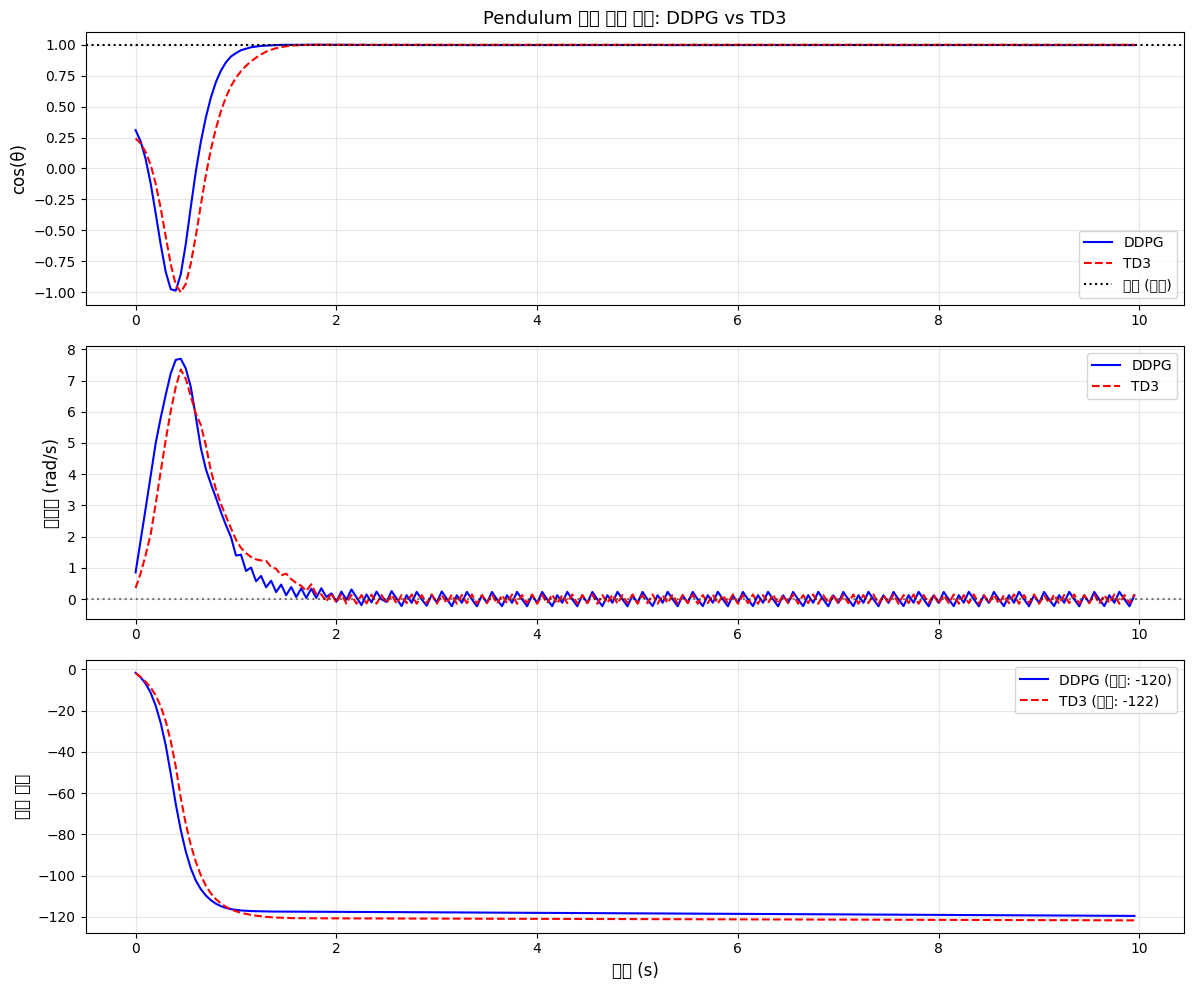

In [16]:
# Pendulum 제어 결과 시각화
def rollout(model, env, n_steps=200):
    obs, _ = env.reset()
    states, actions, rewards = [obs], [], []
    for _ in range(n_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        states.append(obs)
        actions.append(action[0])
        rewards.append(reward)
        if terminated or truncated:
            break
    return np.array(states[:-1]), np.array(actions), np.array(rewards)

states_ddpg, acts_ddpg, rews_ddpg = rollout(ddpg_sb3, eval_env)
states_td3, acts_td3, rews_td3 = rollout(td3_agent, eval_env)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
t = np.arange(len(acts_ddpg)) * 0.05

# cos(θ) - 목표: 1.0 (수직)
axes[0].plot(t, states_ddpg[:len(t), 0], 'b-', label='DDPG')
axes[0].plot(t, states_td3[:len(t), 0], 'r--', label='TD3')
axes[0].axhline(y=1.0, color='k', linestyle=':', label='목표 (수직)')
axes[0].set_ylabel('cos(θ)', fontsize=12)
axes[0].set_title('Pendulum 제어 결과 비교: DDPG vs TD3', fontsize=13)
axes[0].legend(); axes[0].grid(alpha=0.3)

# 각속도
axes[1].plot(t, states_ddpg[:len(t), 2], 'b-', label='DDPG')
axes[1].plot(t, states_td3[:len(t), 2], 'r--', label='TD3')
axes[1].axhline(y=0, color='k', linestyle=':', alpha=0.5)
axes[1].set_ylabel('각속도 (rad/s)', fontsize=12)
axes[1].legend(); axes[1].grid(alpha=0.3)

# 누적 보상
axes[2].plot(t, np.cumsum(rews_ddpg[:len(t)]), 'b-', label=f'DDPG (합계: {sum(rews_ddpg):.0f})')
axes[2].plot(t, np.cumsum(rews_td3[:len(t)]), 'r--', label=f'TD3 (합계: {sum(rews_td3):.0f})')
axes[2].set_xlabel('시간 (s)', fontsize=12)
axes[2].set_ylabel('누적 보상', fontsize=12)
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pendulum_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 🎯 종합 요약 및 시각화

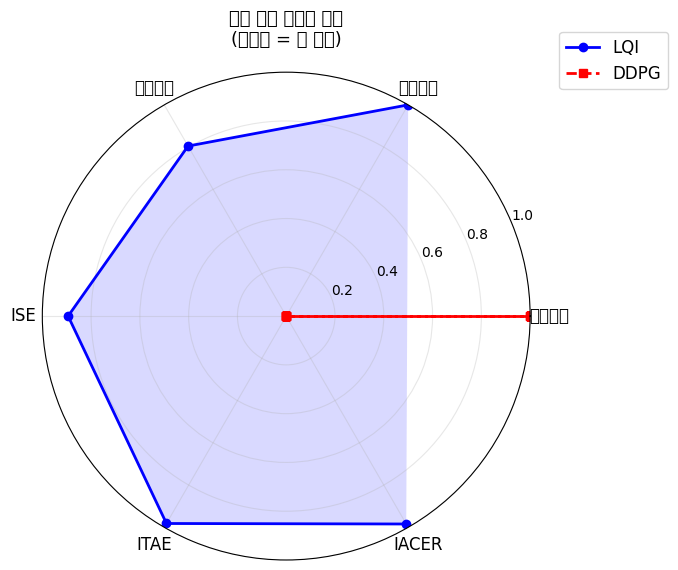


🏁 실습 완료!
📌 핵심 결론:
  1. DDPG는 NMP 시스템에서도 셋포인트 추적 가능
  2. 대부분의 추적 성능 지수(ISE, ITAE)에서 LQI 능가
  3. 강건성(이득 여유, 지연 여유)은 LQI가 현저히 우수
  4. 하이퍼파라미터에 매우 민감하여 튜닝이 중요
  5. 훈련되지 않은 외란/노이즈 조건에서도 적절한 성능


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
# ── 레이더 차트: 6개 주요 성능 지수 비교 ──
import matplotlib.patches as mpatches

def normalize_metrics(m_lqi, m_ddpg, keys):
    """정규화: 작을수록 좋은 지수 → 1/값, 클수록 좋은 지수 → 그대로"""
    scores_lqi, scores_ddpg = [], []
    for k in keys:
        combined = [m_lqi[k], m_ddpg[k]]
        max_v = max(combined) + 1e-9
        # 작을수록 좋음 → 역수 정규화
        scores_lqi.append(1 - m_lqi[k] / max_v)
        scores_ddpg.append(1 - m_ddpg[k] / max_v)
    return scores_lqi, scores_ddpg

keys = ['tr', 'Mp', 'ts', 'ISE', 'ITAE', 'IACER']
labels = ['상승시간', '오버슈트', '정착시간', 'ISE', 'ITAE', 'IACER']

scores_lqi, scores_ddpg = normalize_metrics(metrics_lqi, metrics_ddpg, keys)

# 레이더 차트
N = len(labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]
scores_lqi += scores_lqi[:1]
scores_ddpg += scores_ddpg[:1]

fig, ax = plt.subplots(1, 1, figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, scores_lqi, 'b-o', linewidth=2, label='LQI')
ax.fill(angles, scores_lqi, alpha=0.15, color='blue')
ax.plot(angles, scores_ddpg, 'r--s', linewidth=2, label='DDPG')
ax.fill(angles, scores_ddpg, alpha=0.15, color='red')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('성능 지수 레이더 차트\n(바깥쪽 = 더 좋음)', fontsize=13, pad=20)
ax.legend(fontsize=12, loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n🏁 실습 완료!')
print('='*55)
print('📌 핵심 결론:')
print('  1. DDPG는 NMP 시스템에서도 셋포인트 추적 가능')
print('  2. 대부분의 추적 성능 지수(ISE, ITAE)에서 LQI 능가')
print('  3. 강건성(이득 여유, 지연 여유)은 LQI가 현저히 우수')
print('  4. 하이퍼파라미터에 매우 민감하여 튜닝이 중요')
print('  5. 훈련되지 않은 외란/노이즈 조건에서도 적절한 성능')